# Dependencies

In [ ]:
%pip install --upgrade Pillow
%pip install nnsight transformers plotly kaleido accelerate bitsandbytes
%pip install matplotlib pandas seaborn
%pip install --upgrade jinja2

In [2]:
import os
import json
import pickle
import torch
import nnsight
import kaleido
import plotly.express as px
from nnsight import LanguageModel, util
import argparse
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
import plotly.graph_objects as go
import plotly.io as pio


/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import logging, sys

LOG_FILE = 'atp_run.log'

logging.basicConfig(
    level    = logging.INFO,
    format   = '%(asctime)s  %(message)s',
    datefmt  = '%H:%M:%S',
    handlers = [
        logging.FileHandler(LOG_FILE),    # persists on disk when you disconnect
        logging.StreamHandler(sys.stdout) # also visible in notebook when connected
    ]
)
log = logging.getLogger()
log.info("Logging initialised — writing to %s", LOG_FILE)

23:38:31  Logging initialised — writing to atp_run.log


# Config

In [17]:
import os

model_name = 'allenai/OLMo-7B-0724-Instruct-hf'
output_dir = '/atp_results'  
flip_to   = " Male"
flip_from = " Female"

condition_pairs = [
    ('Prostatitis', 'multiple sclerosis', flip_from, flip_to),
    ('Prostatitis', 'sarcoidosis',        flip_from, flip_to),
    ('Prostatitis', 'rheumatoid arthristis',flip_from, flip_to),
     ('Prostatitis', 'asthma',         flip_from, flip_to),
     ('Prostatitis', 'essential hypertension',  flip_from, flip_to),
    ('Prostatitis', 'bronchitis',  flip_from, flip_to),
    
]




# Prompts

In [6]:
template = """Compose a brief presentation 
of a patient presenting with {0}. 
Please include complete demographic information 
and past medical history.You must start with 'Gender: '.
Do not include any header."""

system = "You are a helpful clinical assistant."

def make_prompt(condition, system, template):
    messages = [{"role": "user",
                 "content": system + "\n\n" + template.format(condition)}]
    base = tokenizer.apply_chat_template(
               messages, tokenize=False, add_generation_prompt=True)
    return base + "Gender:" #append Gender: suffix to force the LLM to generate Male/Female as the first output token

def tokenize_prompts(clean_prompt, corrupt_prompt):
    clean_tokens   = tokenizer(clean_prompt,   return_tensors='pt')['input_ids'][0]
    corrupt_tokens = tokenizer(corrupt_prompt, return_tensors='pt')['input_ids'][0]
    return clean_tokens, corrupt_tokens

def calc_offset_suffix(clean_tokens, corrupt_tokens):
    first_mismatch = min(len(clean_tokens), len(corrupt_tokens))
    for i, (ct, rt) in enumerate(zip(clean_tokens, corrupt_tokens)):
        if ct != rt:
            first_mismatch = i
            log.info("  First mismatch at pos %d: clean=%s  corrupt=%s",
                     i, repr(tokenizer.decode(ct)), repr(tokenizer.decode(rt)))
            break
    log.info("Shared prefix length (offset): %d", first_mismatch)

    suffix_len = 0
    num_clean_tokens = len(clean_tokens)
    num_corrupt_tokens = len(corrupt_tokens)
    for i in range(1, min(num_clean_tokens, num_corrupt_tokens) + 1):
        if clean_tokens[-i] == corrupt_tokens[-i]:
            suffix_len += 1
        else:
            break
    return first_mismatch, suffix_len

# Load Model

In [7]:
from transformers import BitsAndBytesConfig

tokenizer = AutoTokenizer.from_pretrained(model_name)
from transformers import BitsAndBytesConfig

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

llm = LanguageModel(
    model_name, 
    device_map='cuda:0', 
    quantization_config=quant_config, #Optimize for memory space 
    dispatch=True
)

log.info("Model loaded. GPU allocated: %.2f GB", torch.cuda.memory_allocated() / 1e9)


log.info("CUDA available: %s", torch.cuda.is_available())
log.info("CUDA device: %s", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
param_device = next(llm.model.parameters()).device
log.info("Model parameters are on: %s", param_device)

23:38:36  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
23:38:36  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allenai/OLMo-7B-0724-Instruct-hf/aba3d33d766a33a44677e3a163f0fe2d1010d90a/config.json "HTTP/1.1 200 OK"
23:38:36  HTTP Request: GET https://huggingface.co/api/resolve-cache/models/allenai/OLMo-7B-0724-Instruct-hf/aba3d33d766a33a44677e3a163f0fe2d1010d90a/config.json "HTTP/1.1 200 OK"
23:38:36  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
23:38:36  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allenai/OLMo-7B-0724-Instruct-hf/aba3d33d766a33a44677e3a163f0fe2d1010d90a/tokenizer_config.json "HTTP/1.1 200 OK"
23:38:36  HTTP Request: GET https://huggingface.co/api/resolve-cache/models/allenai/OLMo-7B-0724-Instruct-hf/aba3d33d766a33a44677e3a163f0fe2d1010d90a/

23:38:36  Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
23:38:37  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/main/tokenizer.json "HTTP/1.1 307 Temporary Redirect"
23:38:37  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allenai/OLMo-7B-0724-Instruct-hf/aba3d33d766a33a44677e3a163f0fe2d1010d90a/tokenizer.json "HTTP/1.1 200 OK"
23:38:37  HTTP Request: GET https://huggingface.co/api/resolve-cache/models/allenai/OLMo-7B-0724-Instruct-hf/aba3d33d766a33a44677e3a163f0fe2d1010d90a/tokenizer.json "HTTP/1.1 200 OK"
23:38:37  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
23:38:37  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/main/special_tokens_map.json "HTTP/1.1 307 Temporary Redirect"
23:38:37  HTTP Request: HEAD https://hugg

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

23:38:40  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/aba3d33d766a33a44677e3a163f0fe2d1010d90a/model-00001-of-00003.safetensors "HTTP/1.1 302 Found"
23:38:40  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/aba3d33d766a33a44677e3a163f0fe2d1010d90a/model-00003-of-00003.safetensors "HTTP/1.1 302 Found"
23:38:40  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/aba3d33d766a33a44677e3a163f0fe2d1010d90a/model-00002-of-00003.safetensors "HTTP/1.1 302 Found"
23:38:40  HTTP Request: GET https://huggingface.co/api/models/allenai/OLMo-7B-0724-Instruct-hf/xet-read-token/aba3d33d766a33a44677e3a163f0fe2d1010d90a "HTTP/1.1 200 OK"
23:38:40  HTTP Request: GET https://huggingface.co/api/models/allenai/OLMo-7B-0724-Instruct-hf/xet-read-token/aba3d33d766a33a44677e3a163f0fe2d1010d90a "HTTP/1.1 200 OK"
23:38:40  HTTP Request: GET https://huggingface.co/api/models/allenai/OLMo-7B-0724-Instruct-hf/xet

Loading weights: 100%|██████████| 226/226 [00:02<00:00, 106.39it/s]


23:39:03  HTTP Request: HEAD https://huggingface.co/allenai/OLMo-7B-0724-Instruct-hf/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
23:39:03  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allenai/OLMo-7B-0724-Instruct-hf/aba3d33d766a33a44677e3a163f0fe2d1010d90a/generation_config.json "HTTP/1.1 200 OK"
23:39:03  HTTP Request: GET https://huggingface.co/api/resolve-cache/models/allenai/OLMo-7B-0724-Instruct-hf/aba3d33d766a33a44677e3a163f0fe2d1010d90a/generation_config.json "HTTP/1.1 200 OK"
23:39:03  Model loaded. GPU allocated: 4.48 GB
23:39:03  CUDA available: True
23:39:03  CUDA device: NVIDIA A10
23:39:03  Model parameters are on: cuda:0


# Helper Functions

- Check memory space
- Collect clean activations
- Collect corrupt activations



In [ ]:
def mem():
    return torch.cuda.memory_allocated() / 1e9

def collect_clean_activations(clean_prompt,  n_layers):
    clean_acts = {}
    log.info("[MEM] Before clean forward pass:      %.2f GB", mem())

    with torch.no_grad():
        with llm.trace(clean_prompt) as tracer:
            for layer_idx in range(n_layers):
                z = llm.model.layers[layer_idx].mlp.down_proj.output
                clean_acts[layer_idx] = z.save()
            logits_clean = llm.lm_head.output
            clean_pred   = logits_clean[0, -1, :].argmax().save()

    log.info("[MEM] After clean forward pass:        %.2f GB", mem())

    for layer_idx in range(n_layers):
        clean_acts[layer_idx] = clean_acts[layer_idx].cpu()

    torch.cuda.empty_cache()
    log.info("[MEM] After moving clean_acts to CPU:  %.2f GB", mem())

    decoded_token = tokenizer.decode(clean_pred.item())
    return clean_acts, decoded_token

def collect_corrupt_activations(corrupt_prompt, flip_to_id, flip_from_id, n_layers):
    corrupt_acts = {}
    proxies = {}
    with llm.trace(corrupt_prompt) as tracer:
        for layer_idx in range(n_layers):
            z = llm.model.layers[layer_idx].mlp.down_proj.output
            z.retain_grad()
            proxies[layer_idx] = z
            corrupt_acts[layer_idx] = z.save()

        logits       = llm.lm_head.output
        corrupt_pred = logits[0, -1, :].argmax().save()
        metric       = logits[0, -1, flip_to_id] - logits[0, -1, flip_from_id]
        metric.backward() # to compute gradient


        test_grad_saved = proxies[0].grad.save()

    print("grad saved inside trace:", test_grad_saved.abs().sum().item())
    print("grad via .grad outside trace:", corrupt_acts[0].grad)

    decoded_token = tokenizer.decode(corrupt_pred.item())
    return corrupt_acts, decoded_token

# Main run

In [10]:
import gc

#Clean variables and empty cache to save memory
for var_name in ['corrupt_acts', 'clean_acts', 'atp_scores']:
    if var_name in globals():
        del globals()[var_name]

torch.cuda.empty_cache()
gc.collect()
print("GPU memory freed. Allocated: %.2f GB", torch.cuda.memory_allocated() / 1e9)


GPU memory freed. Allocated: %.2f GB 4.484875264


In [23]:

N_LAYERS  = len(llm.model.layers)

current_path = os.getcwd()
output_dir = os.path.join(current_path, 'atp_results')

condition_last_subtoken_profiles_corrupt = []

condition_token_profiles_corrupt = []    



flip_to_id   = tokenizer(flip_to,   add_special_tokens=False)['input_ids'][0]
flip_from_id = tokenizer(flip_from, add_special_tokens=False)['input_ids'][0]
log.info("flip_to_id=%d  flip_from_id=%d  N_LAYERS=%d", flip_to_id, flip_from_id, N_LAYERS)


01:43:28  flip_to_id=23588  flip_from_id=26993  N_LAYERS=32


In [19]:

# For every condition pair
for pair_idx, (clean_condition, corrupt_condition, flip_from, flip_to) in enumerate(condition_pairs):

    flip_to_id   = tokenizer(flip_to,   add_special_tokens=False)['input_ids'][0]
    flip_from_id = tokenizer(flip_from, add_special_tokens=False)['input_ids'][0]

    log.info("════ Condition pair %d/%d: '%s' → '%s' ════",
             pair_idx + 1, len(condition_pairs), corrupt_condition, flip_from)

    # Prepare prompts 
    clean_prompt   = make_prompt(clean_condition,   system, template)
    corrupt_prompt = make_prompt(corrupt_condition, system, template)

    # Tokenize prompts
    clean_tokens, corrupt_tokens = tokenize_prompts(clean_prompt, corrupt_prompt)
    num_clean_tokens   = len(clean_tokens)
    num_corrupt_tokens = len(corrupt_tokens)

    #Calculate last subtoken of condition token
    offset, suffix_len = calc_offset_suffix(clean_tokens, corrupt_tokens)
    n_cond_clean   = num_clean_tokens   - offset - suffix_len
    n_cond_corrupt = num_corrupt_tokens - offset - suffix_len
    last_subtoken_pos = offset + n_cond_corrupt - 1

    # Collect clean activations
    clean_acts, clean_decoded = collect_clean_activations(clean_prompt, N_LAYERS)

    # Collect corrupt activations
    corrupt_acts, corrupt_decoded = collect_corrupt_activations(
        corrupt_prompt, flip_to_id, flip_from_id, N_LAYERS)

    atp_scores_all_tokens = np.zeros((N_LAYERS, num_corrupt_tokens))
    atp_condition_scores = np.zeros(N_LAYERS)

    #Compute AtP score 
    for layer_idx in range(N_LAYERS):
        x_corrupt    = corrupt_acts[layer_idx]
        corrupt_grad = corrupt_acts[layer_idx].grad
        x_clean      = clean_acts[layer_idx]
        dev, dtype   = x_corrupt.device, x_corrupt.dtype

        clean_last_subtoken = offset + n_cond_clean - 1
        donor_vec = x_clean[:, clean_last_subtoken : clean_last_subtoken + 1, :].to(dev, dtype)
        donor_expanded = donor_vec.expand_as(x_corrupt)
        diff = donor_expanded - x_corrupt

        
        atp_scores_all_tokens[layer_idx] = (
            (diff * corrupt_grad).sum(dim=-1).squeeze().detach().cpu().float().numpy()
        )

        #to optimize for memory capacity
        del x_corrupt, corrupt_grad, x_clean, donor_vec, donor_expanded, diff

    del clean_acts, corrupt_acts
    torch.cuda.empty_cache()
    gc.collect()

    #Save results
    condition_token_profiles_corrupt.append(atp_condition_scores)
    condition_last_subtoken_profiles_corrupt.append(atp_scores_all_tokens[:, last_subtoken_pos])

    
    token_labels = [f"{tokenizer.decode(t)}_{i}" for i, t in enumerate(corrupt_tokens)]
    condition_results = {
        'atp_scores_corrupt_grad':    atp_scores_all_tokens,
        'atp_condition_corrupt_grad': atp_condition_scores,
        'token_labels':      token_labels,
        'layer_labels':      list(range(N_LAYERS)),
        'last_subtoken_pos': last_subtoken_pos,
        'offset':            offset,
        'suffix_len':        suffix_len,
        'n_cond_clean':      n_cond_clean,
        'n_cond_corrupt':    n_cond_corrupt,
        'corrupt_condition': corrupt_condition,
        'clean_condition':   clean_condition,
        'flip_from':         flip_from,
        'flip_to':           flip_to,
    }
    fname = corrupt_condition.replace(' ', '_') + '_atp.pkl'
    pickle.dump(condition_results, open(os.path.join(output_dir, fname), 'wb'))

# Average across conditions
avg_profile_corrupt = np.stack(condition_last_subtoken_profiles_corrupt).mean(axis=0)
avg_cond_corrupt    = np.stack(condition_token_profiles_corrupt).mean(axis=0)

pickle.dump(
    {
        'avg_profile_corrupt_grad':      avg_profile_corrupt,
        'avg_cond_token_corrupt_grad':   avg_cond_corrupt,
        'condition_pairs': condition_pairs,
    },
    open(os.path.join(output_dir, 'atp_avg_profile.pkl'), 'wb')
)
log.info("Saved atp_avg_profile.pkl (averaged across conditions)")


23:41:32  ════ Condition pair 1/6: 'multiple sclerosis' → ' Female' ════
23:41:32    First mismatch at pos 27: clean=' Pro'  corrupt=' multiple'
23:41:32  Shared prefix length (offset): 27
23:41:32  [MEM] Before clean forward pass:      5.33 GB
23:41:32  [MEM] After clean forward pass:        5.35 GB
23:41:32  [MEM] After moving clean_acts to CPU:  5.33 GB
grad saved inside trace: 5088.0
grad via .grad outside trace: tensor([[[ 0.0136,  0.0042, -0.0168,  ...,  0.0111, -0.0125,  0.0023],
         [ 0.0017,  0.0020, -0.0049,  ...,  0.0026, -0.0070, -0.0007],
         [ 0.0103,  0.0009, -0.0019,  ..., -0.0082, -0.0056, -0.0004],
         ...,
         [-0.0422,  0.0393, -0.0408,  ...,  0.0320, -0.0311,  0.0332],
         [-0.0505, -0.0156, -0.0114,  ...,  0.0396, -0.0247,  0.0217],
         [-0.0022,  0.0432,  0.0019,  ..., -0.1738, -0.0481, -0.0080]]],
       device='cuda:0', dtype=torch.bfloat16)
23:41:32  ════ Condition pair 2/6: 'sarcoidosis' → ' Female' ════
23:41:32    First mismatc

# Create Result Plots


Figure saved to: /home/ubuntu/atp_results2/avg_atp_profile.png


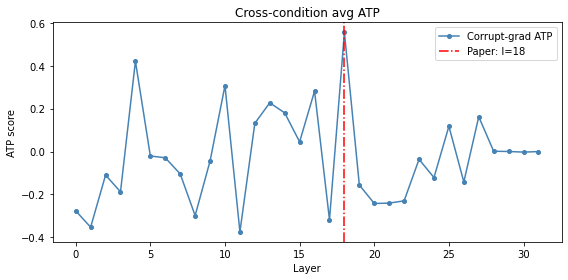

Figure saved to: /home/ubuntu/atp_results2/per_condition_atp_profiles.png


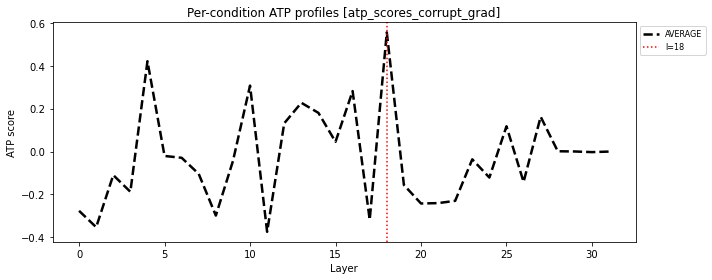

In [21]:
import os

# --- Helper to handle saving ---
def handle_save(fig, save_path):
    if save_path:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")

def plot_heatmap(scores, token_labels, title="", top_k=15, save_path=None):
    """Heatmap plotting AtP scores on the top-k most activated tokens."""
    importance = np.abs(scores).max(axis=0)
    top_idx_sorted = sorted(np.argsort(importance)[::-1][:top_k])

    heatmap_data = scores[:, top_idx_sorted]
    short_labels = [token_labels[i].rsplit('_', 1)[0] for i in top_idx_sorted]

    vmax = np.abs(heatmap_data).max()
    if vmax == 0: vmax = 1.0

    fig = plt.figure(figsize=(12, 6))
    sns.heatmap(
        heatmap_data,
        xticklabels=short_labels,
        yticklabels=list(range(scores.shape[0])),
        cmap='RdBu', center=0, vmin=-vmax, vmax=vmax,
        linewidths=0.3, linecolor='grey',
        cbar_kws={'label': 'ATP score'}
    )
    plt.xlabel('Token')
    plt.ylabel('Layer')
    plt.title(f'{title}\nTop-{top_k} tokens by peak ATP', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    handle_save(fig, save_path) # <--- ADDED
    plt.show()

def plot_cross_condition_avg(avg_profile, save_path=None):
    """Average AtP score Line graph"""
    layers = list(range(len(avg_profile)))
    fig = plt.figure(figsize=(8, 4))

    plt.plot(layers, avg_profile, marker='o', markersize=4, color='steelblue', label='Corrupt-grad ATP')
    plt.axvline(x=18, color='red', linestyle='-.', label='Paper: l=18')

    plt.xlabel('Layer')
    plt.ylabel('ATP score')
    plt.title(f'Cross-condition avg ATP')
    plt.legend()
    plt.tight_layout()
    
    handle_save(fig, save_path) # <--- ADDED
    plt.show()

def plot_per_condition_profiles(condition_pairs, output_dir, score_key, avg_profile, extract_fn, save_path=None):
    """Per Condition AtP score Line graph"""
    layers = list(range(len(avg_profile)))
    fig = plt.figure(figsize=(10, 4))

    for clean_cond, corrupt_cond, flip_from, flip_to in condition_pairs:
        fname = corrupt_cond.replace(' ', '_') + '_atp.pkl'
        try:
            with open(f'{output_dir}/{fname}', 'rb') as f:
                r = pickle.load(f)
            profile = extract_fn(r)
            plt.plot(layers, profile, linewidth=1.2, alpha=0.7, label=corrupt_cond)
        except FileNotFoundError:
            continue

    plt.plot(layers, avg_profile, color='black', linewidth=2.5, linestyle='--', label='AVERAGE')
    plt.axvline(x=18, color='red', linestyle=':', label='l=18')

    plt.xlabel('Layer')
    plt.ylabel('ATP score')
    plt.title(f'Per-condition ATP profiles [{score_key}]')
    plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    
    handle_save(fig, save_path) # <--- ADDED
    plt.show()

# --- Execution with Saving Logic ---

# 1. Save Average Profile Line Graph
plot_cross_condition_avg(
    avg_profile_full, 
    save_path=f'{output_dir}/avg_atp_profile.png'
)

# 2. Save Per-Condition Profile Comparisons
plot_per_condition_profiles(
    condition_pairs, output_dir,
    score_key='atp_scores_corrupt_grad',
    avg_profile=avg_profile_full,
    extract_fn=lambda r: r['atp_scores_corrupt_grad'][:, r['last_subtoken_pos']],
    save_path=f'{output_dir}/per_condition_atp_profiles.png'
)

# 3. Save the Cross-Condition Heatmap
# Note: You'll need to update plot_cross_condition_avg_heatmap to pass save_path to plot_heatmap
plot_cross_condition_avg_heatmap(
    condition_pairs, output_dir, 
    top_k=15
    # Inside your function, ensure you call: plot_heatmap(..., save_path=f'{output_dir}/avg_heatmap.png')
)

In [15]:
import seaborn as sns


def plot_heatmap(scores, token_labels, title="", top_k=15):
    """Heatmap plotting AtP scores on the top-k most activated tokens."""
    importance = np.abs(scores).max(axis=0)
    top_idx_sorted = sorted(np.argsort(importance)[::-1][:top_k])

    heatmap_data = scores[:, top_idx_sorted]
    short_labels = [token_labels[i].rsplit('_', 1)[0] for i in top_idx_sorted]

    vmax = np.abs(heatmap_data).max()
    if vmax == 0: vmax = 1.0

    fig1 = plt.figure(figsize=(12, 6))
    sns.heatmap(
        heatmap_data,
        xticklabels=short_labels,
        yticklabels=list(range(scores.shape[0])),
        cmap='RdBu', center=0, vmin=-vmax, vmax=vmax,
        linewidths=0.3, linecolor='grey',
        cbar_kws={'label': 'ATP score'}
    )
    plt.xlabel('Token')
    plt.ylabel('Layer')
    plt.title(f'{title}\nTop-{top_k} tokens by peak ATP', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show(fig1)
    
def plot_per_condition_heatmap(condition_pairs, output_dir, score_key='atp_scores_corrupt_grad', title_prefix="Full-sequence ATP", top_k=15):
    """Heatmap plotting per-condition AtP scores on the top-k most activated tokens"""
    for clean_cond, corrupt_cond, flip_from, flip_to in condition_pairs:
        fname = corrupt_cond.replace(' ', '_') + '_atp.pkl'
        try:
            with open(f'{output_dir}/{fname}', 'rb') as f:
                r = pickle.load(f)
        except FileNotFoundError:
            continue

        plot_heatmap(
            r[score_key], r['token_labels'],
            title=f'{title_prefix} {corrupt_cond} ({flip_from}→{flip_to})',
            top_k=top_k
        )

def plot_cross_condition_avg_heatmap(condition_pairs, output_dir, score_key='atp_scores_corrupt_grad', title_prefix="Cross-condition avg ATP", top_k=15):
    """Heatmap plotting average AtP scores on the top-k most activated tokens."""
    all_data = []

   
    for clean_cond, corrupt_cond, flip_from, flip_to in condition_pairs:
        fname = corrupt_cond.replace(' ', '_') + '_atp.pkl'
        try:
            with open(f'{output_dir}/{fname}', 'rb') as f:
                all_data.append(pickle.load(f))
        except FileNotFoundError:
            continue

    if not all_data: return

    #  Find safe uniform lengths to avoid tokenizer merging differences
    min_prefix = min(r['offset'] for r in all_data)
    min_suffix = min(r['suffix_len'] for r in all_data)

    all_aligned = []

   
    for r in all_data:
        scores = r[score_key]
        cond_pos = r['last_subtoken_pos']

    
        prefix_scores = scores[:, :min_prefix]
        cond_score = scores[:, cond_pos:cond_pos + 1]

        # Slice from the end to guarantee alignment with the tail of the prompt
        suffix_scores = scores[:, -min_suffix:] if min_suffix > 0 else np.zeros((scores.shape[0], 0))

        aligned = np.concatenate([prefix_scores, cond_score, suffix_scores], axis=1)
        all_aligned.append(aligned)

    #  Create shared labels 
    
    ref_labels = all_data[0]['token_labels']
    shared_labels = ref_labels[:min_prefix] + ['[CONDITION]'] + ref_labels[-min_suffix:]

    avg_scores = np.stack(all_aligned).mean(axis=0)
    plot_heatmap(
        avg_scores, shared_labels,
        title=f'{title_prefix} ({len(all_aligned)} conditions)',
        top_k=top_k
    )

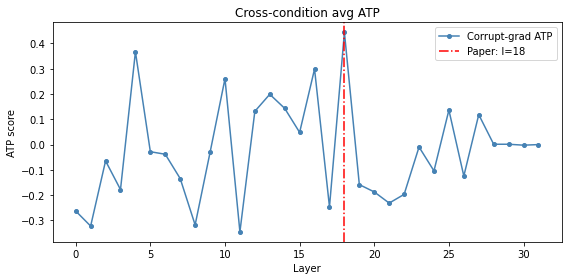

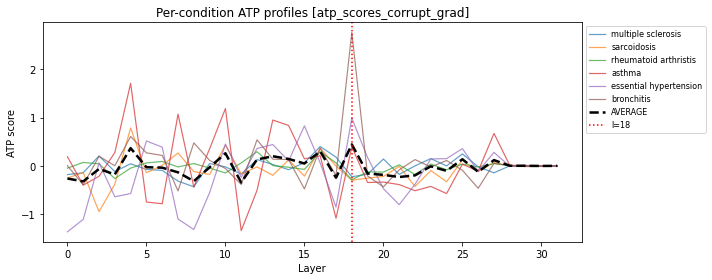

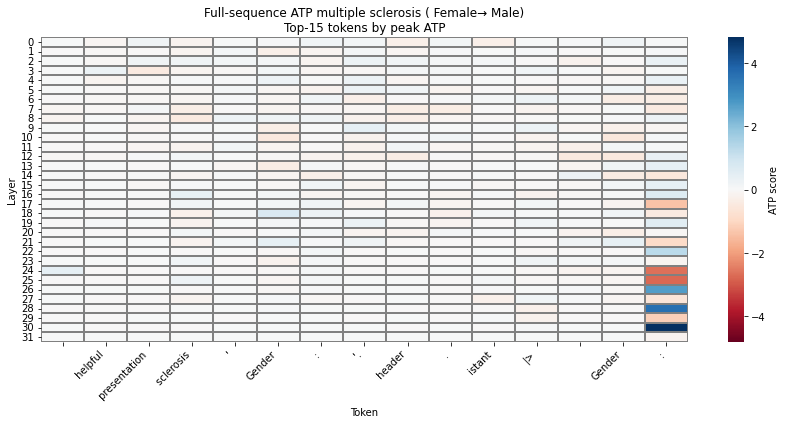

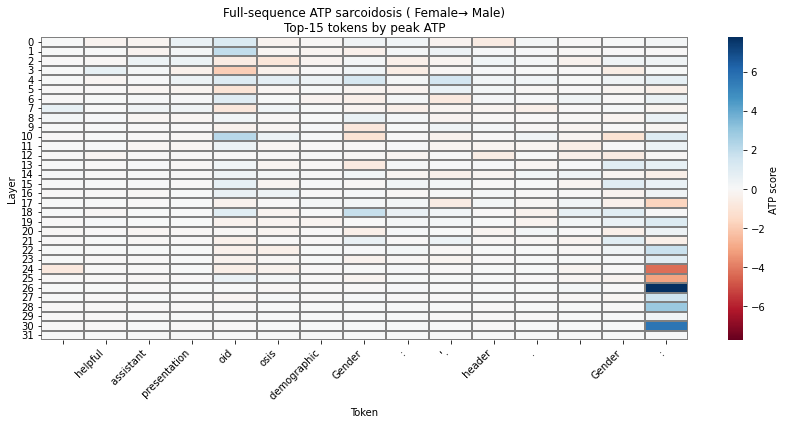

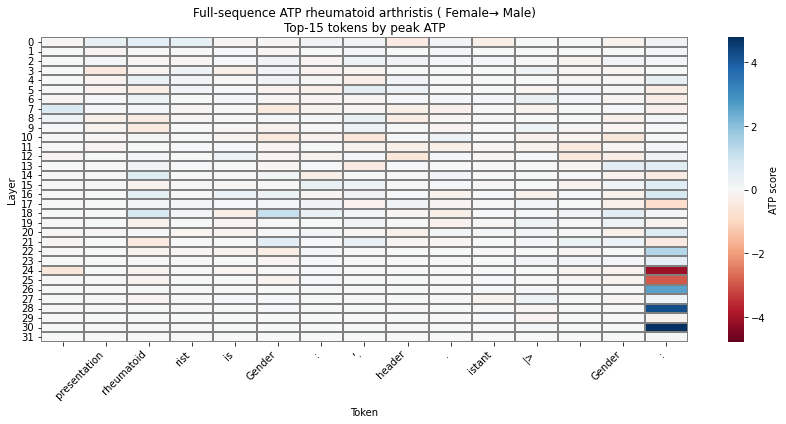

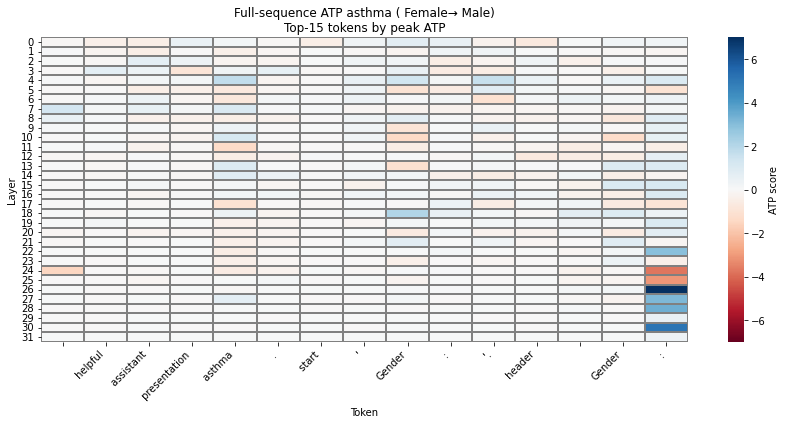

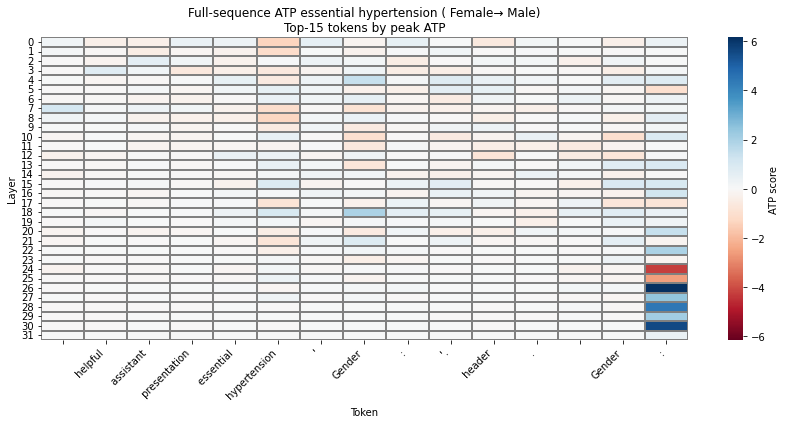

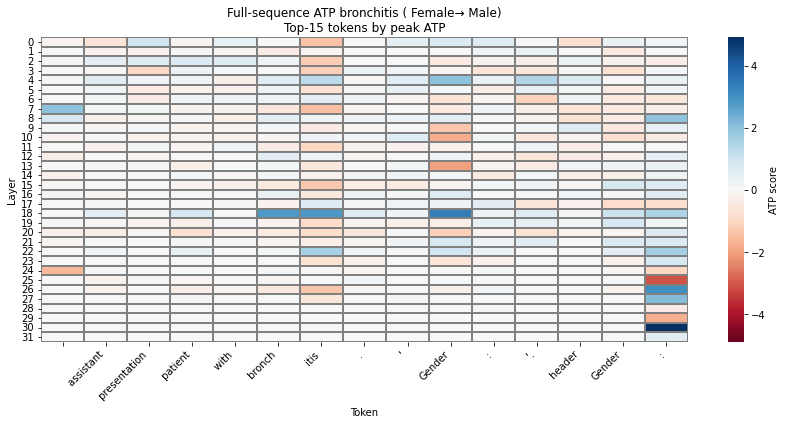

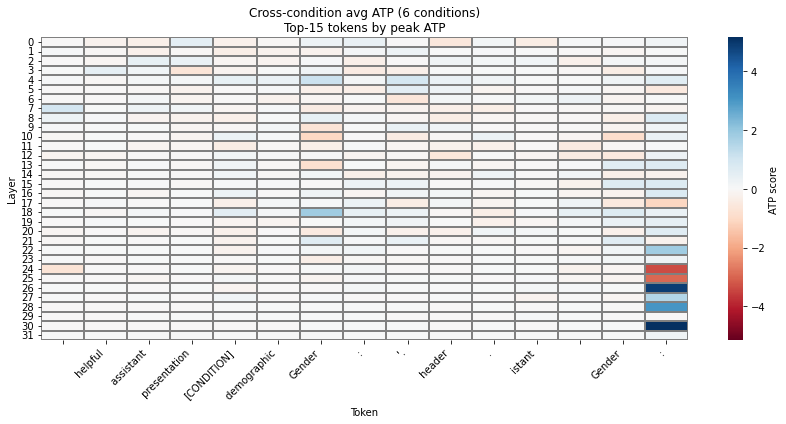

In [24]:

with open(f'{output_dir}/atp_avg_profile.pkl', 'rb') as f:
    avg_data = pickle.load(f)

condition_pairs = avg_data['condition_pairs']
avg_profile_full = avg_data['avg_profile_corrupt_grad']
avg_profile_cond = avg_data['avg_cond_token_corrupt_grad']


plot_cross_condition_avg(avg_profile_full)

plot_per_condition_profiles(
    condition_pairs, output_dir,
    score_key='atp_scores_corrupt_grad',
    avg_profile=avg_profile_full,
    extract_fn=lambda r: r['atp_scores_corrupt_grad'][:, r['last_subtoken_pos']]
)


plot_per_condition_heatmap(condition_pairs, output_dir, top_k=15)
plot_cross_condition_avg_heatmap(condition_pairs, output_dir, top_k=15)